# 文件: chart_20_1.py

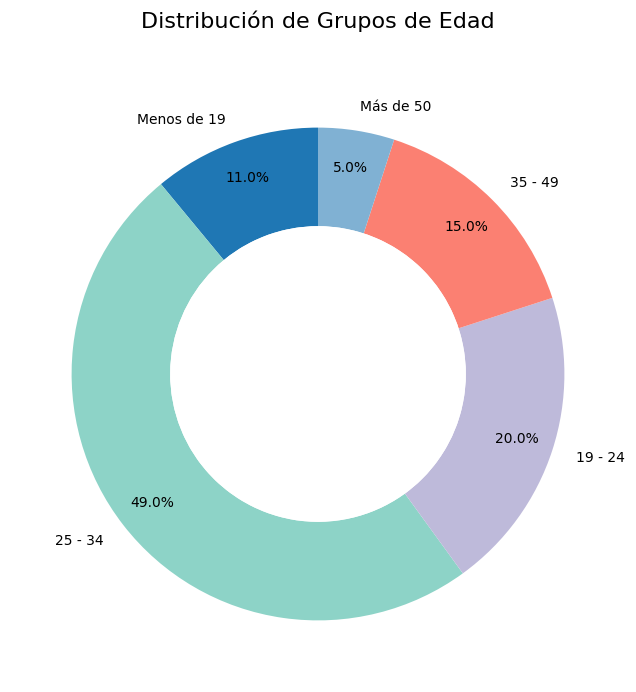

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
grupos_edad = ["Menos de 19", "25 - 34", "19 - 24", "35 - 49", "Más de 50"]
porcentajes = [11, 49, 20, 15, 5]
colores = ["#1f77b4", "#8dd3c7", "#bebada", "#fb8072", "#80b1d3"]  # Colores personalizados, se pueden ajustar

# Crear un gráfico de donut
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    porcentajes,
    labels=grupos_edad,
    autopct="%1.1f%%",  # Mostrar formato de porcentaje
    startangle=90,
    colors=colores,
    pctdistance=0.85,  # Distancia de las etiquetas de porcentaje desde el centro
    wedgeprops={"width": 0.4},  # Ancho del donut
)

# Agregar un círculo central (para que el donut sea más evidente)
circulo_central = plt.Circle((0, 0), 0.6, color="black", fc="white", linewidth=0)
ax.add_artist(circulo_central)

# Establecer el título
ax.set_title("Distribución de Grupos de Edad", fontsize=16, y=1.05)

# Mostrar el gráfico
plt.show()

# 文件: chart_20_2.py

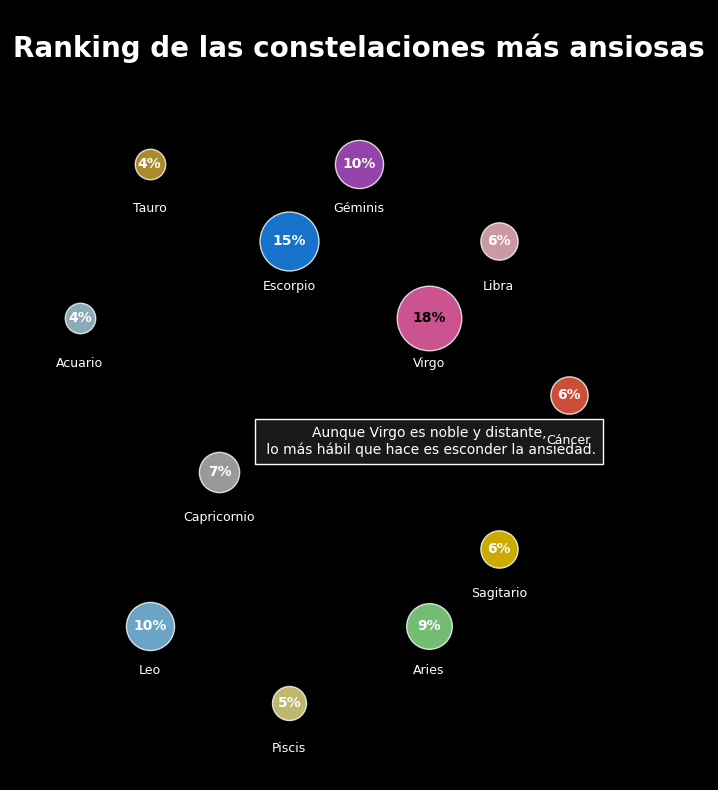

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Preparación de datos
constelaciones = [
    "Tauro", "Acuario", "Capricornio", "Leo", "Piscis", "Aries", "Sagitario", "Cáncer",
    "Libra", "Géminis", "Virgo", "Escorpio"
]
porcentajes = [4, 4, 7, 10, 5, 9, 6, 6, 6, 10, 18, 15]
# Establecer manualmente las coordenadas de cada constelación para facilitar el diseño (se pueden ajustar según el diseño)
coords = [
    (0.2, 0.8), (0.1, 0.6), (0.3, 0.4), (0.2, 0.2), (0.4, 0.1), (0.6, 0.2),
    (0.7, 0.3), (0.8, 0.5), (0.7, 0.7), (0.5, 0.8), (0.6, 0.6), (0.4, 0.7)
]
# Colores de las burbujas correspondientes (esquema de colores de ejemplo, se pueden ajustar)
colores = [
    "#D4AF37", "#ADD8E6", "#C0C0C0", "#87CEFA", "#F0E68C", "#90EE90",
    "#FFD700", "#FF6347", "#FFC0CB", "#BA55D3", "#FF69B4", "#1E90FF"
]
# Texto de anotación especial para Virgo
texto_virgo = "Aunque Virgo es noble y distante,\n lo más hábil que hace es esconder la ansiedad."

# Crear un lienzo
fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# Ocultar los ejes
ax.set_xticks([])
ax.set_yticks([])

# Dibujar burbujas + anotaciones
for constelacion, p, (x, y), color in zip(constelaciones, porcentajes, coords, colores):
    # Dibujar burbujas (simuladas por un diagrama de dispersión)
    ax.scatter(
        x, y, 
        s=p * 120,  # El tamaño de la burbuja está relacionado con el porcentaje de ansiedad
        c=color, 
        alpha=0.8,
        edgecolors='white', 
        linewidths=1
    )
    # Dibujar el texto del porcentaje
    color_texto = 'white' if p != 18 else 'black'  # Invertir el color del texto para Virgo
    ax.text(
        x, y, 
        f"{p}%", 
        ha='center', 
        va='center', 
        fontsize=10, 
        color=color_texto, 
        fontweight='bold'
    )
    # Dibujar el nombre de la constelación
    ax.text(
        x, y - 0.05, 
        constelacion, 
        ha='center', 
        va='top', 
        fontsize=9, 
        color='white'
    )

# Texto de descripción especial para Virgo
virgo_x, virgo_y = coords[constelaciones.index("Virgo")]
ax.text(
    virgo_x, virgo_y - 0.18, 
    texto_virgo, 
    ha='center', 
    va='bottom', 
    fontsize=10, 
    color='white', 
    linespacing=1.2,
    # Fix: Cambiar el formato de color CSS al formato de tupla RGBA
    bbox=dict(facecolor=(1, 1, 1, 0.1), edgecolor='white', pad=5)
)

# Agregar un título
ax.text(
    0.5, 0.95, 
    "Ranking de las constelaciones más ansiosas", 
    ha='center', 
    va='center', 
    fontsize=20, 
    color='white', 
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# 文件: chart_20_3.py

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_29620\3115686211.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=cm.get_cmap('Blues_r'), alpha=0.3


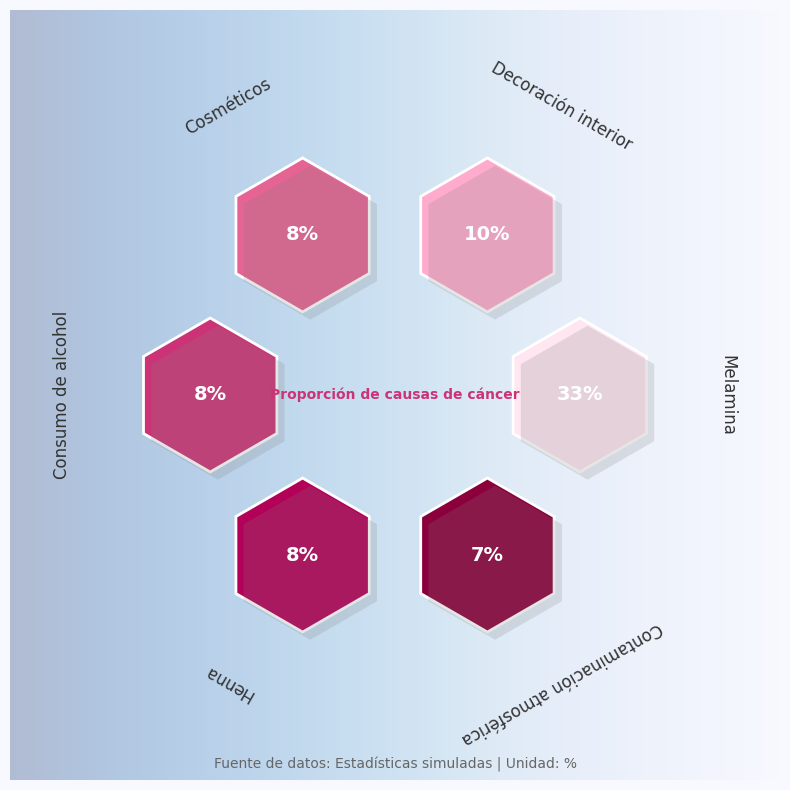

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

# ======================== 1. Datos y configuración básica ========================
labels = ["Melamina", "Decoración interior", "Cosméticos", "Consumo de alcohol", "Henna", "Contaminación atmosférica"]
sizes = [33, 10, 8, 8, 8, 7]

# Coordenadas de distribución en anillo hexagonal (conversión de coordenadas polares a cartesianas)
theta = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
radius = 1.2  # Controla el radio del anillo hexagonal
x = radius * np.cos(theta)
y = radius * np.sin(theta)

# Paleta de colores degradados personalizada (de rosa claro a rosa oscuro)
cmap = LinearSegmentedColormap.from_list(
    'pink_cmap', 
    ['#FFE6F0', '#FFABCD', '#E66493', '#CC3377', '#B30059', '#8B003C'],
    N=len(labels)
)

# ======================== 2. Inicializar el lienzo y los ejes ========================
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#F8F8FF')  # Fondo azul claro
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axis('off')  # Ocultar los ejes

# ======================== 3. Dibujar hexágonos tridimensionales (con sombra + degradado) ========================
for i in range(len(labels)):
    # Hexágono principal (relleno degradado)
    hex_main = RegularPolygon(
        (x[i], y[i]), numVertices=6, radius=0.5, 
        facecolor=cmap(i), edgecolor='white', linewidth=2
    )
    ax.add_patch(hex_main)
    
    # Hexágono de sombra (simular efecto tridimensional)
    hex_shadow = RegularPolygon(
        (x[i] + 0.05, y[i] - 0.05), numVertices=6, radius=0.5, 
        facecolor='gray', alpha=0.2, edgecolor='none'
    )
    ax.add_patch(hex_shadow)
    
    # Dibujar el número de proporción (centrado, en negrita)
    ax.text(
        x[i], y[i], f"{sizes[i]}%", 
        ha='center', va='center', 
        fontsize=14, fontweight='bold', 
        color='white'
    )
    
    # Dibujar el texto de la etiqueta (diseño circular, ajustar el ángulo)
    text_angle = np.rad2deg(theta[i]) - 90  # Ajustar el ángulo del texto al hexágono
    ax.text(
        x[i] * 1.8, y[i] * 1.8, labels[i], 
        ha='center', va='center', 
        fontsize=12, color='#333333', 
        rotation=text_angle
    )

# ======================== 4. Agregar título y decoración ========================
# Título central
ax.text(
    0, 0, "Proporción de causas de cáncer", 
    ha='center', va='center', 
    fontsize=10, fontweight='bold', 
    color='#CC3377'
)

# Descripción en la parte inferior
ax.text(
    0, -2.4, "Fuente de datos: Estadísticas simuladas | Unidad: %", 
    ha='center', va='center', 
    fontsize=10, color='#666666', 
)

# Fondo degradado (difusión desde el centro hacia afuera)
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient_img = np.tile(gradient, (256, 1))
ax.imshow(
    gradient_img, extent=(-2.5, 2.5, -2.5, 2.5), 
    cmap=cm.get_cmap('Blues_r'), alpha=0.3
)

plt.tight_layout()
plt.show()

# 文件: chart_20_4.py

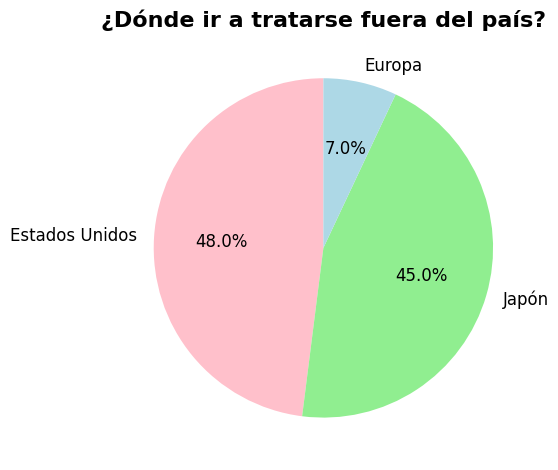

In [6]:
import matplotlib.pyplot as plt

# 数据
paises = ["Estados Unidos", "Japón", "Europa"]
porcentajes = [48, 45, 7]
colores = ["pink", "lightgreen", "lightblue"]

# 创建饼图
plt.pie(
    porcentajes,
    labels=paises,
    colors=colores,
    autopct="%1.1f%%",  # 显示百分比
    startangle=90,  # 起始角度
    textprops={"fontsize": 12}
)

# 添加标题
plt.title("¿Dónde ir a tratarse fuera del país?", fontsize=16, fontweight="bold")

# 调整布局（避免标签挤压）
plt.tight_layout()

# 显示图表
plt.show()

# 文件: chart_20_5.py

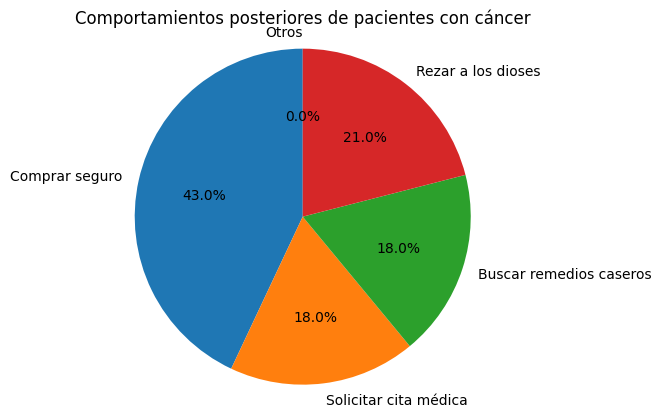

In [5]:
import matplotlib.pyplot as plt

# Datos
etiquetas = ['Comprar seguro', 'Solicitar cita médica', 'Buscar remedios caseros', 'Rezar a los dioses', 'Otros']
tamaños = [43, 18, 18, 21, 0]  # Proporciones de cada parte, la suma es 100, se pueden ajustar según sea necesario
colores = ['#FFA07A', '#90EE90', '#FFC0CB', '#87CEFA', '#D3D3D3']  # Colores de cada parte, se pueden personalizar

# Dibujar un gráfico circular
fig, ax = plt.subplots()
ax.pie(tamaños, labels=etiquetas, autopct='%1.1f%%', startangle=90)
ax.axis('equal')  # Asegurar que el gráfico circular sea un círculo perfecto

# Agregar un título
plt.title('Comportamientos posteriores de pacientes con cáncer')

# Mostrar el gráfico
plt.show()

# 文件: chart_20_6.py

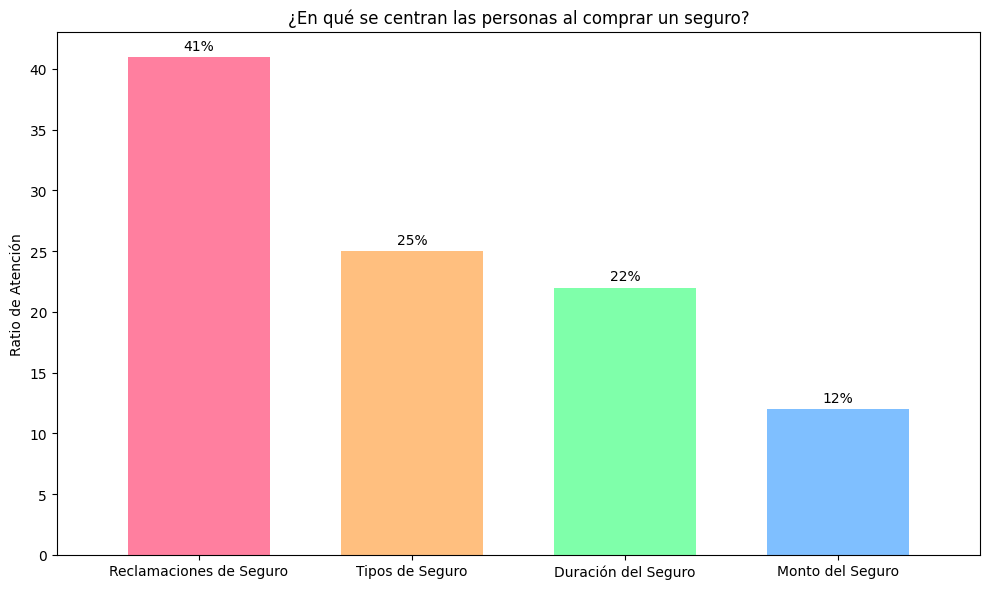

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
etiquetas = ['Reclamaciones de Seguro', 'Tipos de Seguro', 'Duración del Seguro', 'Monto del Seguro']
valores = [41, 25, 22, 12]
colores = ['#ff7f9f', '#ffbf7f', '#7fffaa', '#7fbfff']  # Colores correspondientes

# Ajustar la posición del eje x, aumentar el espaciado
x = np.arange(len(etiquetas)) * 1.2  # Ampliar el espaciado del eje x (espaciado original × 1.2)

# Crear el lienzo y aumentar adecuadamente el ancho
fig, ax = plt.subplots(figsize=(10, 6))  # Ampliar el lienzo para acomodar un espaciado más ancho
rectangulos = ax.bar(x, valores, color=colores, width=0.8)  # Controlar el ancho de las barras, evitar que sean demasiado anchas

# Agregar etiquetas de valores
for rectangulo in rectangulos:
    altura = rectangulo.get_height()
    ax.annotate('{}%'.format(altura),
                xy=(rectangulo.get_x() + rectangulo.get_width() / 2, altura),
                xytext=(0, 3),  # Desplazamiento de la posición de la etiqueta
                textcoords="offset points",
                ha='center', va='bottom')

# Configurar las marcas y etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=10)  # Puedes reducir adecuadamente el tamaño de la fuente
ax.set_ylabel('Ratio de Atención')
ax.set_title('¿En qué se centran las personas al comprar un seguro?')

# Ajustar el rango del eje x, evitar que las etiquetas de los extremos queden pegadas al borde
ax.set_xlim(x[0] - 0.8, x[-1] + 0.8)

plt.tight_layout()  # Ajustar automáticamente la disposición
plt.show()